In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import sys
import os
# Adds parent diretory for imports
sys.path.append(os.path.abspath('..'))
# Add scripts folder for imports
sys.path.append('../scripts')

✅ Data loaded successfully

🔍 Raw Data:
   customer_id  tenure  monthly_charges  total_charges        contract  \
0            1      52            54.20        2818.40  Month-to-month   
1            2      15            35.28         529.20  Month-to-month   
2            3      72            78.24        5633.28  Month-to-month   
3            4      61            80.24        4894.64        One year   
4            5      21            39.38         826.98  Month-to-month   

  payment_method internet_service tech_support online_security  support_calls  \
0         Credit              DSL           No             Yes              1   
1          Debit              DSL           No              No              2   
2          Debit              DSL           No              No              0   
3           Cash            Fiber          Yes             Yes              0   
4            UPI            Fiber           No              No              4   

  churn  
0    No  
1    No 

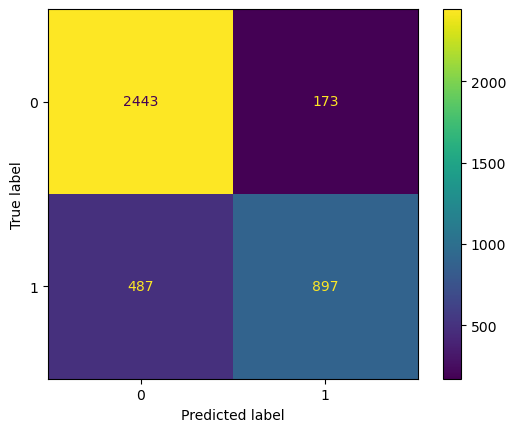

CV Mean: 0.8397
CV Std: 0.0055

🔮 Prediction Result:
Not High Risk (Probability: 11.14%)


In [5]:
from dataloader import DataLoader
from data_cleaner import DataCleaner
from feature_engineering import FeatureEngineer
from churn_model import ChurnModel
from config_paths import RAW_DATA_PATH


def main():

    # 1. Load raw data
    loader = DataLoader(RAW_DATA_PATH)
    df = loader.load_data()

    if df is not None:

        print("\n🔍 Raw Data:")
        print(df.head())

        # 2. Clean data
        cleaner = DataCleaner(df)
        cleaner.inspect_data()
        clean_df = cleaner.clean_data()

        print("\n✅ Cleaned Data:")
        print(clean_df.head())

        # 3. Feature Engineering (drop columns etc.)
        fe = FeatureEngineer(clean_df)
        model_df = fe.create_features()

        print("\n🚀 Model Data (after feature engineering):")
        print(model_df.head())

        # 4. Model Training (USE model_df ONLY)
        model = ChurnModel(model_df)

        model.prepare_data()
        model.build_preprocessor()
        model.load_models()
        model.train_models()
        model.evaluate_xgboost()

        # 5. Prediction Example
        result = model.predict_risk({
            'tenure': 52,
            'monthly_charges': 54.20,
            'contract': 'Month-to-month',
            'payment_method': 'Credit',
            'internet_service': 'DSL',
            'tech_support': 'No',
            'online_security': 'Yes',
            'support_calls': 1
        })

        print("\n🔮 Prediction Result:")
        print(result)

    else:
        print("❌ Data not loaded")


if __name__ == "__main__":
    main()